# CNN — Reconnaissance de Chiffres & Lettres (0-9 + A-Z)
### Projet IA M1 — Dr Khalid Gaber

---

**Architecture :**
- Un **seul modèle CNN unifié** → 36 classes (10 chiffres + 26 lettres)
- Dataset **MNIST** (chiffres) + **EMNIST Letters** (lettres) fusionnés et **équilibrés**
- Techniques anti-biais : rééchantillonnage, class weights, data augmentation
- BatchNormalization + Dropout + L2 Regularization + ReduceLROnPlateau

**Corrections v2 (anti-overfitting) :**
- L2 regularization sur les couches Dense
- Dropout augmenté sur les couches denses (0.60 / 0.50)
- EarlyStopping avec `restore_best_weights=True`
- ModelCheckpoint → sauvegarde automatique du meilleur modèle
- ReduceLROnPlateau plus agressif (factor=0.3, patience=2)
- Évaluation finale sur `best_model.keras` (pas le dernier epoch)

**Plan du notebook :**
1. Installation & imports
2. Chargement des données (MNIST + EMNIST)
3. Équilibrage et fusion des datasets
4. Prétraitement et augmentation
5. Construction du modèle CNN
6. Callbacks & entraînement
7. Évaluation & courbes d'apprentissage
8. Matrice de confusion & précision par classe
9. Test sur données bruitées
10. Sauvegarde & prédiction rapide

In [1]:
# ── Installation des dépendances ────────────────────────────────────────
# Décommenter si besoin :
# !pip install tensorflow numpy matplotlib seaborn scikit-learn Pillow
# !pip install tensorflow-datasets   # fallback EMNIST
%pip install --quiet seaborn scikit-learn Pillow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.patches import Patch

# ── Reproductibilité ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Désactiver GPU si non disponible (retirer si GPU dispo)
tf.config.set_visible_devices([], 'GPU')

print(f" TensorFlow : {tf.__version__}")
print(f" NumPy      : {np.__version__}")

# ── Labels ────────────────────────────────────────────────────────────────
DIGITS    = [str(i) for i in range(10)]        # '0'…'9'
LETTERS   = [chr(i) for i in range(65, 91)]    # 'A'…'Z'
CLASSES   = DIGITS + LETTERS                   # 36 classes
N_CLASSES = len(CLASSES)

print(f" Classes    : {N_CLASSES} → {CLASSES}")

✅ TensorFlow : 2.21.0
✅ NumPy      : 1.26.4
✅ Classes    : 36 → ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


## 2. Chargement des données — MNIST (chiffres 0-9)

In [3]:
def load_mnist():
    """Charge MNIST. Retourne X (N,28,28,1) float32 et y (N,) int."""
    print("[MNIST] Chargement...")
    (X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
    X_tr = X_tr.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    X_te = X_te.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    print(f"[MNIST] Train : {X_tr.shape} | Test : {X_te.shape}")
    print(f"[MNIST] Distribution : {dict(sorted(Counter(y_tr).items()))}")
    return X_tr, y_tr, X_te, y_te

X_mnist_tr, y_mnist_tr, X_mnist_te, y_mnist_te = load_mnist()

[MNIST] Chargement...
[MNIST] Train : (60000, 28, 28, 1) | Test : (10000, 28, 28, 1)
[MNIST] Distribution : {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


## 2.2 Chargement EMNIST Letters (lettres A-Z)

**Option A — fichier `.mat` officiel :**
Télécharger depuis https://www.nist.gov/itl/products-and-services/emnist-dataset → `emnist-letters.mat`
Placer dans le même dossier que ce notebook.

**Option B — `tensorflow_datasets` (fallback automatique si .mat absent)**

In [4]:
EMNIST_MAT_PATH = Path('emnist-letters.mat')


def load_emnist_mat(mat_path=EMNIST_MAT_PATH):
    """Charge depuis le fichier .mat officiel NIST."""
    from scipy.io import loadmat
    print(f"[EMNIST] Chargement depuis : {mat_path}")
    data       = loadmat(str(mat_path))
    train_data = data['dataset'][0][0][0]
    test_data  = data['dataset'][0][0][1]

    X_tr = train_data[0][0][0].astype('float32') / 255.0
    y_tr = train_data[0][0][1].flatten() - 1   # 1-26 → 0-25
    X_te = test_data[0][0][0].astype('float32') / 255.0
    y_te = test_data[0][0][1].flatten() - 1

    # Reshape (N,784) → (N,28,28,1) + correction transposition EMNIST
    X_tr = np.transpose(X_tr.reshape(-1, 28, 28, 1), (0, 2, 1, 3))
    X_te = np.transpose(X_te.reshape(-1, 28, 28, 1), (0, 2, 1, 3))
    print(f"[EMNIST .mat] Train : {X_tr.shape} | Test : {X_te.shape}")
    return X_tr, y_tr, X_te, y_te


def load_emnist_tfds():
    """Fallback via tensorflow_datasets."""
    import tensorflow_datasets as tfds
    print("[EMNIST] Chargement via tensorflow_datasets...")
    ds_tr = tfds.load('emnist/letters', split='train', as_supervised=True)
    ds_te = tfds.load('emnist/letters', split='test',  as_supervised=True)

    def extract(ds):
        imgs, labs = [], []
        for img, lbl in ds:
            img = tf.cast(img, tf.float32) / 255.0
            img = tf.transpose(img, perm=[1, 0, 2])
            imgs.append(img.numpy())
            labs.append(int(lbl.numpy()) - 1)
        return np.array(imgs), np.array(labs)

    X_tr, y_tr = extract(ds_tr)
    X_te, y_te = extract(ds_te)
    print(f"[EMNIST tfds] Train : {X_tr.shape} | Test : {X_te.shape}")
    return X_tr, y_tr, X_te, y_te


def load_emnist():
    """Essaie .mat → tfds → erreur claire."""
    if EMNIST_MAT_PATH.exists():
        return load_emnist_mat()
    print(f"[WARN] {EMNIST_MAT_PATH} introuvable → tentative tensorflow_datasets")
    try:
        return load_emnist_tfds()
    except ImportError:
        raise RuntimeError(
            "EMNIST non disponible.\n"
            "Solution 1 : télécharger emnist-letters.mat depuis\n"
            "  https://www.nist.gov/itl/products-and-services/emnist-dataset\n"
            "Solution 2 : pip install tensorflow-datasets"
        )


X_emnist_tr, y_emnist_tr, X_emnist_te, y_emnist_te = load_emnist()

[EMNIST] Chargement depuis : emnist-letters.mat
[EMNIST .mat] Train : (124800, 28, 28, 1) | Test : (20800, 28, 28, 1)


## 3. Fusion et équilibrage des datasets

In [5]:
def balance_dataset(X, y, samples_per_class=None, seed=SEED):
    """
    Rééchantillonne chaque classe pour avoir exactement `samples_per_class`
    exemples (sous- ou sur-échantillonnage selon besoin).
    """
    rng     = np.random.RandomState(seed)
    classes = np.unique(y)
    counts  = Counter(y)
    if samples_per_class is None:
        samples_per_class = min(counts.values())

    X_out, y_out = [], []
    for cls in classes:
        idx    = np.where(y == cls)[0]
        chosen = rng.choice(idx, samples_per_class,
                            replace=(len(idx) < samples_per_class))
        X_out.append(X[chosen])
        y_out.append(np.full(samples_per_class, cls))

    X_bal = np.concatenate(X_out)
    y_bal = np.concatenate(y_out)
    perm  = rng.permutation(len(X_bal))
    return X_bal[perm], y_bal[perm]


def merge_and_balance(X_mnist_tr, y_mnist_tr, X_mnist_te, y_mnist_te,
                      X_emnist_tr, y_emnist_tr, X_emnist_te, y_emnist_te,
                      samples_per_class_train=5000, samples_per_class_test=800):
    """
    Décale labels EMNIST (+10), fusionne MNIST+EMNIST, équilibre.
    """
    y_em_tr = y_emnist_tr + 10
    y_em_te = y_emnist_te + 10

    X_tr_raw = np.concatenate([X_mnist_tr, X_emnist_tr])
    y_tr_raw = np.concatenate([y_mnist_tr, y_em_tr])
    X_te_raw = np.concatenate([X_mnist_te, X_emnist_te])
    y_te_raw = np.concatenate([y_mnist_te, y_em_te])

    print(f"Avant équilibrage — Train : {len(X_tr_raw)} | Test : {len(X_te_raw)}")
    d = dict(sorted(Counter(y_tr_raw).items()))
    print(f"Distribution train : min={min(d.values())} max={max(d.values())}")

    X_tr, y_tr = balance_dataset(X_tr_raw, y_tr_raw, samples_per_class_train)
    X_te, y_te = balance_dataset(X_te_raw, y_te_raw, samples_per_class_test)

    print(f"Après équilibrage  — Train : {len(X_tr)} ({samples_per_class_train}/classe)"
          f" | Test : {len(X_te)} ({samples_per_class_test}/classe)")
    return X_tr, y_tr, X_te, y_te


# ── Paramètres ────────────────────────────────────────────────────────────
SAMPLES_TRAIN = 5000   # 5 000 × 36 = 180 000 images train
SAMPLES_TEST  = 800    #   800 × 36 =  28 800 images test

X_train, y_train, X_test, y_test = merge_and_balance(
    X_mnist_tr, y_mnist_tr, X_mnist_te, y_mnist_te,
    X_emnist_tr, y_emnist_tr, X_emnist_te, y_emnist_te,
    samples_per_class_train=SAMPLES_TRAIN,
    samples_per_class_test=SAMPLES_TEST,
)

Avant équilibrage — Train : 184800 | Test : 30800
Distribution train : min=4800 max=6742
Après équilibrage  — Train : 180000 (5000/classe) | Test : 28800 (800/classe)


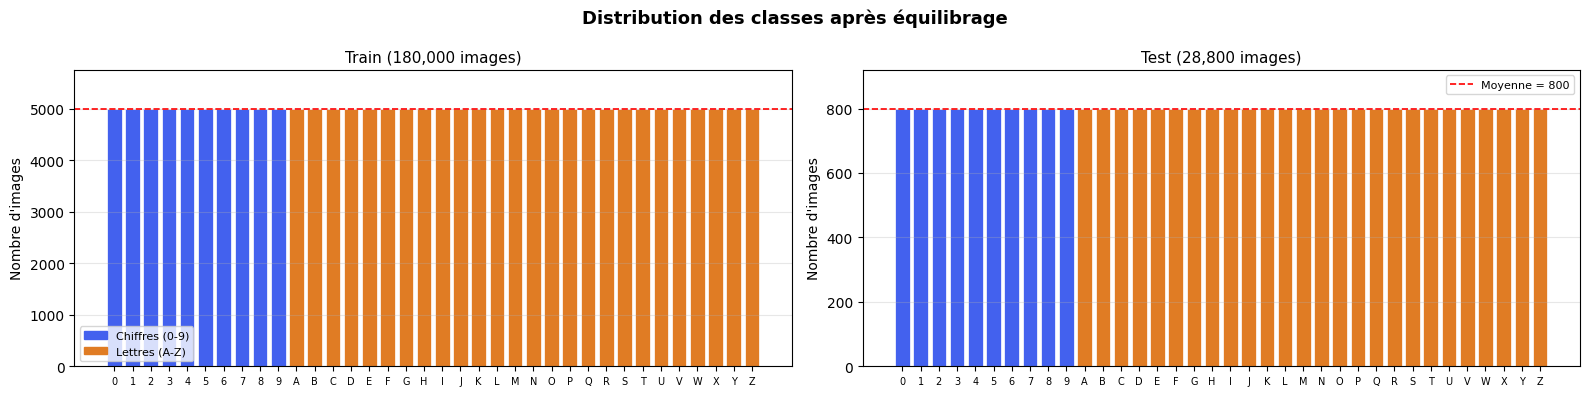

✅ Figure sauvegardée : distribution_classes.png


In [ ]:
# ── Visualisation distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Distribution des classes après équilibrage", fontsize=13, fontweight='bold')

for ax, (y_data, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = Counter(y_data)
    x_pos  = list(range(N_CLASSES))
    vals   = [counts[i] for i in x_pos]
    colors = ['#4361ee'] * 10 + ['#e07c24'] * 26
    ax.bar(x_pos, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(CLASSES, fontsize=7)
    ax.set_title(f'{title} ({len(y_data):,} images)', fontsize=11)
    ax.set_ylabel("Nombre d'images")
    ax.set_ylim(0, max(vals) * 1.15)
    ax.axhline(np.mean(vals), color='red', ls='--', lw=1.2,
               label=f'Moyenne = {np.mean(vals):.0f}')
    ax.grid(axis='y', alpha=0.3)

legend_patches = [Patch(color='#4361ee', label='Chiffres (0-9)'),
                  Patch(color='#e07c24', label='Lettres (A-Z)')]
axes[0].legend(handles=legend_patches, fontsize=8)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée : distribution_classes.png")

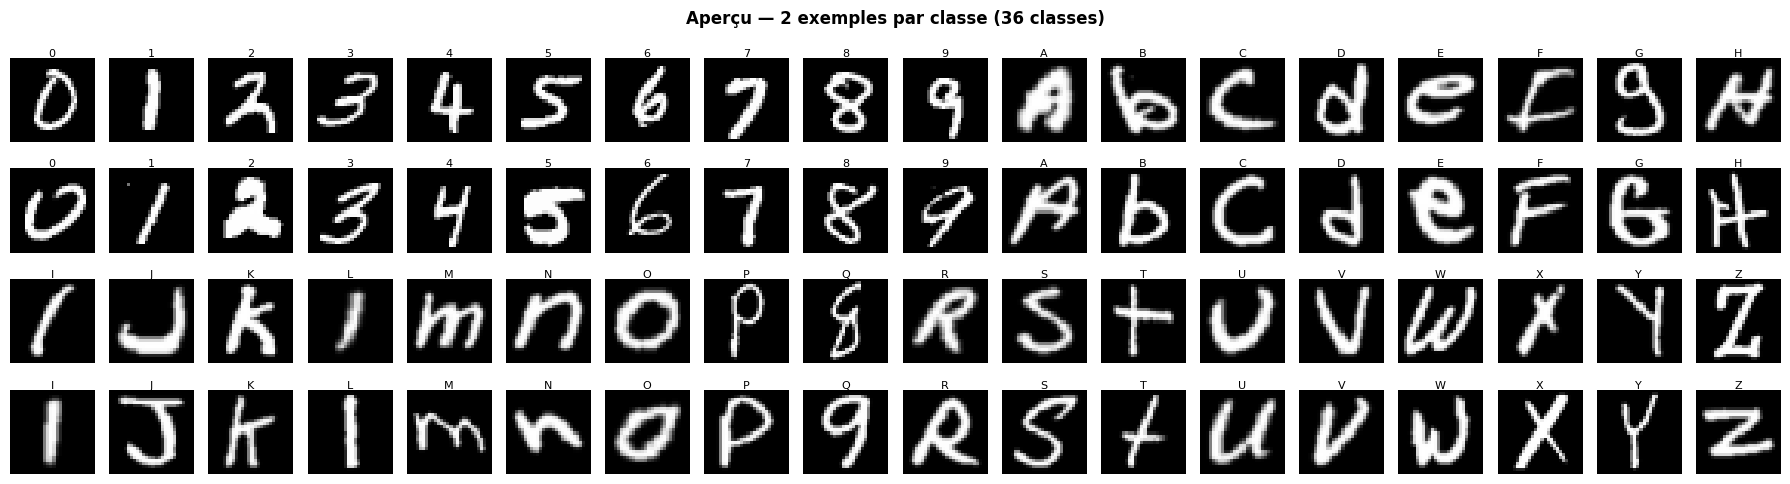

✅ Figure sauvegardée : apercu_donnees.png


In [ ]:
# ── Aperçu des données ───────────────────────────────────────────────────
fig, axes = plt.subplots(4, 18, figsize=(18, 5))
fig.suptitle("Aperçu — 2 exemples par classe (36 classes)", fontsize=12, fontweight='bold')

for col_idx, cls in enumerate(range(N_CLASSES)):
    idxs = np.where(y_train == cls)[0][:2]
    for row_offset, sample_idx in enumerate(idxs):
        row = (col_idx // 18) * 2 + row_offset
        col = col_idx % 18
        if row < 4:
            axes[row, col].imshow(X_train[sample_idx, :, :, 0], cmap='gray')
            axes[row, col].set_title(CLASSES[cls], fontsize=8, pad=1)
            axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('apercu_donnees.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée : apercu_donnees.png")

## 4. Prétraitement & Augmentation de données

In [ ]:
# ── One-hot encoding ────────────────────────────────────────────────────
y_train_cat = to_categorical(y_train, N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

print(f"X_train : {X_train.shape}  y_train_cat : {y_train_cat.shape}")
print(f"X_test  : {X_test.shape}   y_test_cat  : {y_test_cat.shape}")

# ── Class weights ────────────────────────────────────────────────────────
cw_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(N_CLASSES),
    y=y_train,
)
class_weights = dict(enumerate(cw_values))
print(f"\nClass weights — min={min(cw_values):.4f} max={max(cw_values):.4f}")
print("(Valeurs proches de 1.0 = dataset bien équilibré )")

X_train : (180000, 28, 28, 1)  y_train_cat : (180000, 36)
X_test  : (28800, 28, 28, 1)   y_test_cat  : (28800, 36)

Class weights — min=1.0000 max=1.0000
(Valeurs proches de 1.0 = dataset bien équilibré ✅)


✅ ImageDataGenerator configuré


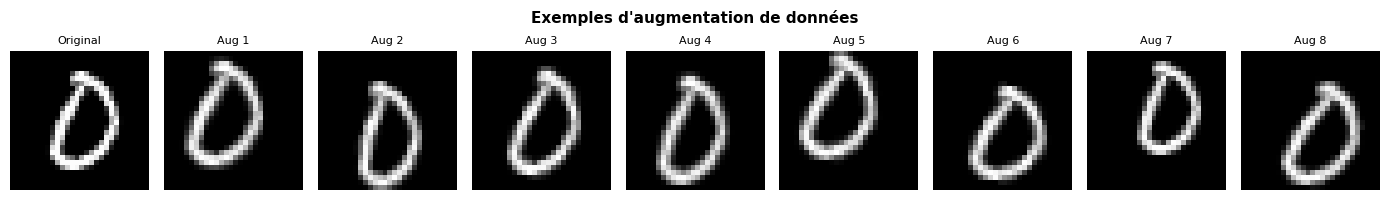

✅ Figure sauvegardée : augmentation_exemples.png


In [ ]:
# ── Data Augmentation ───────────────────────────────────────────────────
# PAS de flip horizontal/vertical : 'b'/'d' et 'p'/'q' sont différents !
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=5.0,
    fill_mode='nearest',
)
datagen.fit(X_train)
print(" ImageDataGenerator configuré")

# ── Aperçu augmentation ──────────────────────────────────────────────────
sample_idx = np.where(y_train == 0)[0][0]
sample_img = X_train[sample_idx:sample_idx + 1]

fig, axes = plt.subplots(1, 9, figsize=(14, 2))
axes[0].imshow(sample_img[0, :, :, 0], cmap='gray')
axes[0].set_title('Original', fontsize=8)
axes[0].axis('off')

gen = datagen.flow(sample_img, batch_size=1)
for i in range(1, 9):
    aug = next(gen)[0]
    axes[i].imshow(aug[:, :, 0], cmap='gray')
    axes[i].set_title(f'Aug {i}', fontsize=8)
    axes[i].axis('off')

fig.suptitle("Exemples d'augmentation de données", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_exemples.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée : augmentation_exemples.png")

## 5.  Construction du modèle CNN (v2 — anti-overfitting)

**Architecture :**
```
Input (28×28×1)
  ↓
Block 1 : Conv2D(32) → BN → ReLU → Conv2D(32) → BN → ReLU → MaxPool → Dropout(0.25)
  ↓
Block 2 : Conv2D(64) → BN → ReLU → Conv2D(64) → BN → ReLU → MaxPool → Dropout(0.25)
  ↓
Block 3 : Conv2D(128) → BN → ReLU → MaxPool → Dropout(0.30)
  ↓
Flatten → Dense(512, L2) → BN → ReLU → Dropout(0.60)   ← Dropout augmenté
  ↓
Dense(256, L2) → BN → ReLU → Dropout(0.50)              ← Dropout augmenté
  ↓
Dense(36) → Softmax
```

**Corrections v2 :**
- L2 regularization (1e-4) sur les Dense → pénalise les grands poids
- Dropout dense : 0.60 / 0.50 (était 0.50 / 0.40) → régularisation plus forte

In [ ]:
def build_cnn(n_classes=36, input_shape=(28, 28, 1), l2_reg=1e-4):
    """
    CNN unifié pour la reconnaissance de 36 caractères.
    v2 : L2 regularization + Dropout plus fort sur les couches Dense.
    """
    reg = regularizers.l2(l2_reg)
    inp = keras.Input(shape=input_shape, name='input')

    # ── Block 1 : 32 filtres ─────────────────────────────────────────────
    x = layers.Conv2D(32, (3,3), padding='same',
                      kernel_initializer='he_uniform', name='conv1_1')(inp)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Activation('relu', name='relu1_1')(x)

    x = layers.Conv2D(32, (3,3), padding='same',
                      kernel_initializer='he_uniform', name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu', name='relu1_2')(x)

    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # ── Block 2 : 64 filtres ─────────────────────────────────────────────
    x = layers.Conv2D(64, (3,3), padding='same',
                      kernel_initializer='he_uniform', name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu', name='relu2_1')(x)

    x = layers.Conv2D(64, (3,3), padding='same',
                      kernel_initializer='he_uniform', name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu', name='relu2_2')(x)

    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.Dropout(0.25, name='drop2')(x)

    # ── Block 3 : 128 filtres ────────────────────────────────────────────
    x = layers.Conv2D(128, (3,3), padding='same',
                      kernel_initializer='he_uniform', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)

    x = layers.MaxPooling2D((2,2), name='pool3')(x)
    x = layers.Dropout(0.30, name='drop3')(x)

    # ── Classifier ───────────────────────────────────────────────────────
    x = layers.Flatten(name='flatten')(x)

    # CORRECTION v2 : L2 + Dropout augmenté
    x = layers.Dense(512, kernel_initializer='he_uniform',
                     kernel_regularizer=reg, name='dense1')(x)
    x = layers.BatchNormalization(name='bn_d1')(x)
    x = layers.Activation('relu', name='relu_d1')(x)
    x = layers.Dropout(0.60, name='drop_d1')(x)   # était 0.50

    x = layers.Dense(256, kernel_initializer='he_uniform',
                     kernel_regularizer=reg, name='dense2')(x)
    x = layers.BatchNormalization(name='bn_d2')(x)
    x = layers.Activation('relu', name='relu_d2')(x)
    x = layers.Dropout(0.50, name='drop_d2')(x)   # était 0.40

    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='CNN_36classes_v2')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


model = build_cnn(n_classes=N_CLASSES)
model.summary()

Model: "CNN_36classes_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (Activation)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (Activation)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (Activation)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (Activation)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_d1 (BatchNormalization)      │ (None, 512)            │         2,04

 Total params: 874,116 (3.33 MB)

 Trainable params: 871,940 (3.33 MB)

 Non-trainable params: 2,176 (8.50 KB)

## 6.  Callbacks & Entraînement

In [ ]:
# ── Hyperparamètres ─────────────────────────────────────────────────────
EPOCHS     = 30     # EarlyStopping arrêtera bien avant si nécessaire
BATCH_SIZE = 128

# ── Callbacks ────────────────────────────────────────────────────────────
callbacks = [

    #  CORRECTION v2 : sauvegarde le MEILLEUR modèle (pas le dernier)
    ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
    ),

    # CORRECTION v2 : arrête si val_loss ne s'améliore plus
    #    restore_best_weights=True → on recharge le meilleur epoch automatiquement
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),

    #  CORRECTION v2 : réduit le LR plus vite et plus fort (factor 0.3 vs 0.5)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),

    # Log CSV pour analyse post-training
    CSVLogger('training_log.csv'),
]

print(" Callbacks configurés :")
print("   • ModelCheckpoint  → best_model.keras (val_accuracy)")
print("   • EarlyStopping    → patience=6, restore_best_weights=True")
print("   • ReduceLROnPlateau → factor=0.3, patience=2")
print("   • CSVLogger        → training_log.csv")
print(f"\n   EPOCHS max  : {EPOCHS}")
print(f"   BATCH_SIZE  : {BATCH_SIZE}")

✅ Callbacks configurés :
   • ModelCheckpoint  → best_model.keras (val_accuracy)
   • EarlyStopping    → patience=6, restore_best_weights=True
   • ReduceLROnPlateau → factor=0.3, patience=2
   • CSVLogger        → training_log.csv

   EPOCHS max  : 30
   BATCH_SIZE  : 128


In [12]:
# ── Pré-génération du dataset augmenté ──────────────────────────────────
# (évite le bug 'ran out of data' avec flow() + steps_per_epoch)
print("Pré-génération du dataset augmenté...")
X_train_aug, y_train_aug = [], []
gen_tmp = datagen.flow(X_train, y_train_cat,
                       batch_size=BATCH_SIZE, seed=SEED, shuffle=True)
steps = len(X_train) // BATCH_SIZE
for _ in range(steps):
    xb, yb = next(gen_tmp)
    X_train_aug.append(xb)
    y_train_aug.append(yb)
X_train_aug = np.concatenate(X_train_aug, axis=0)
y_train_aug = np.concatenate(y_train_aug, axis=0)
print(f"Dataset augmenté prêt : {X_train_aug.shape}")

Pré-génération du dataset augmenté...
Dataset augmenté prêt : (179968, 28, 28, 1)


In [ ]:
# ── Entraînement ────────────────────────────────────────────────────────
print(" Démarrage de l'entraînement...")
print(f"   {len(X_train_aug):,} images train | {len(X_test):,} images test | {N_CLASSES} classes")
print("-" * 60)

history = model.fit(
    X_train_aug, y_train_aug,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_test, y_test_cat),
    class_weight=class_weights,
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)

print("\n Entraînement terminé !")
print(f"   Époques effectuées : {len(history.history['loss'])}")
print(f"   Meilleure val acc  : {max(history.history['val_accuracy'])*100:.2f}%")
print(f"   Meilleure val loss : {min(history.history['val_loss']):.4f}")

🚀 Démarrage de l'entraînement...
   179,968 images train | 28,800 images test | 36 classes
------------------------------------------------------------
Epoch 1/30
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4596 - loss: 2.1160
Epoch 1: val_accuracy improved from None to 0.68208, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 207s 145ms/step - accuracy: 0.6592 - loss: 1.3197 - val_accuracy: 0.6821 - val_loss: 1.3952 - learning_rate: 0.0010
Epoch 2/30
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8477 - loss: 0.6336
Epoch 2: val_accuracy improved from 0.68208 to 0.84764, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 199s 141ms/step - accuracy: 0.8607 - loss: 0.5900 - val_accuracy: 0.8476 - val_loss: 0.6697 - learning_rate: 0.0010
Epoch 3/30
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8871 - loss: 0.4970
Epoch

## 7.  Courbes d'apprentissage

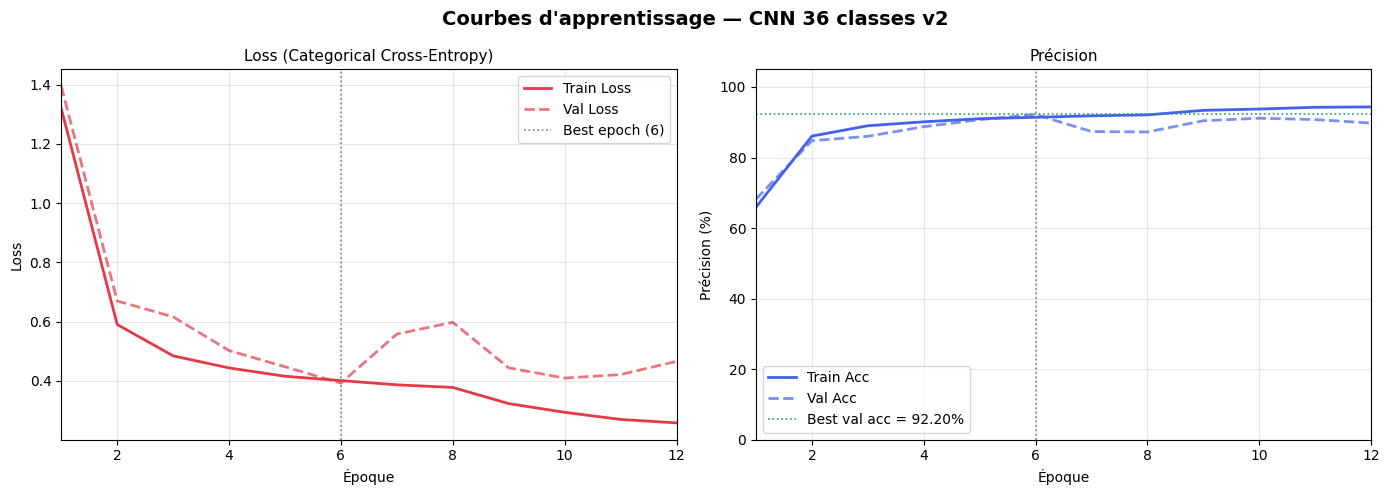

✅ Courbes sauvegardées : courbes_apprentissage.png
   Meilleure val accuracy : 92.20% à l'époque 6


In [ ]:
def plot_training_curves(history, save_path='courbes_apprentissage.png'):
    """Trace et sauvegarde les courbes Loss et Accuracy."""
    hist       = history.history
    epochs_ran = range(1, len(hist['loss']) + 1)
    best_ep    = int(np.argmax(hist['val_accuracy'])) + 1
    best_acc   = max(hist['val_accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Courbes d'apprentissage — CNN 36 classes v2",
                 fontsize=14, fontweight='bold')

    # ── Loss ─────────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs_ran, hist['loss'],     color='#e63946', lw=2,   label='Train Loss')
    ax.plot(epochs_ran, hist['val_loss'], color='#e63946', lw=2,
            linestyle='--', alpha=0.7, label='Val Loss')
    ax.axvline(best_ep, color='gray', linestyle=':', lw=1.2,
               label=f'Best epoch ({best_ep})')
    ax.set_title('Loss (Categorical Cross-Entropy)', fontsize=11)
    ax.set_xlabel('Époque')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(1, len(epochs_ran))

    # ── Accuracy ─────────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(epochs_ran, [v*100 for v in hist['accuracy']],
            color='#4361ee', lw=2, label='Train Acc')
    ax.plot(epochs_ran, [v*100 for v in hist['val_accuracy']],
            color='#4361ee', lw=2, linestyle='--', alpha=0.7, label='Val Acc')
    ax.axvline(best_ep, color='gray', linestyle=':', lw=1.2)
    ax.axhline(best_acc * 100, color='#2a9d5c', linestyle=':', lw=1.2,
               label=f'Best val acc = {best_acc*100:.2f}%')
    ax.set_title('Précision', fontsize=11)
    ax.set_xlabel('Époque')
    ax.set_ylabel('Précision (%)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(1, len(epochs_ran))
    ax.set_ylim(0, 105)

    # ── LR (si disponible) ───────────────────────────────────────────────
    if 'lr' in hist:
        ax2 = axes[1].twinx()
        ax2.plot(epochs_ran, hist['lr'], color='#e07c24',
                 lw=1, linestyle=':', alpha=0.6, label='LR')
        ax2.set_ylabel('Learning Rate', color='#e07c24')
        ax2.tick_params(axis='y', labelcolor='#e07c24')
        ax2.legend(loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Courbes sauvegardées : {save_path}")
    print(f"   Meilleure val accuracy : {best_acc*100:.2f}% à l'époque {best_ep}")


plot_training_curves(history)

## 8.  Évaluation — Rapport de classification & Matrice de confusion

In [ ]:
# ── Chargement du MEILLEUR modèle (sauvegardé par ModelCheckpoint) ────────
#  CORRECTION v2 : on évalue le meilleur epoch, PAS le dernier
print("Chargement du meilleur modèle (best_model.keras)...")
best_model = keras.models.load_model('best_model.keras')

# ── Évaluation finale ────────────────────────────────────────────────────
loss_test, acc_test = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n{'='*45}")
print(f"  Test Loss     : {loss_test:.4f}")
print(f"  Test Accuracy : {acc_test*100:.2f}%")
print(f"{'='*45}")

Chargement du meilleur modèle (best_model.keras)...

  Test Loss     : 0.3919
  Test Accuracy : 92.20%


In [16]:
# ── Prédictions ─────────────────────────────────────────────────────────
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = y_test

# ── Rapport de classification ────────────────────────────────────────────
print("\nRapport de classification détaillé :")
print(classification_report(y_true, y_pred,
                             target_names=CLASSES, digits=3, zero_division=0))


Rapport de classification détaillé :
              precision    recall  f1-score   support

           0      0.870     0.996     0.929       800
           1      0.729     0.998     0.843       800
           2      0.848     0.996     0.916       800
           3      0.972     0.995     0.983       800
           4      0.801     0.993     0.887       800
           5      0.882     0.994     0.935       800
           6      0.891     0.990     0.938       800
           7      0.944     0.995     0.969       800
           8      0.913     0.986     0.948       800
           9      0.790     0.980     0.875       800
           A      0.962     0.919     0.940       800
           B      0.977     0.900     0.937       800
           C      0.970     0.971     0.971       800
           D      0.974     0.882     0.926       800
           E      0.975     0.975     0.975       800
           F      0.987     0.954     0.970       800
           G      0.940     0.669     0.782

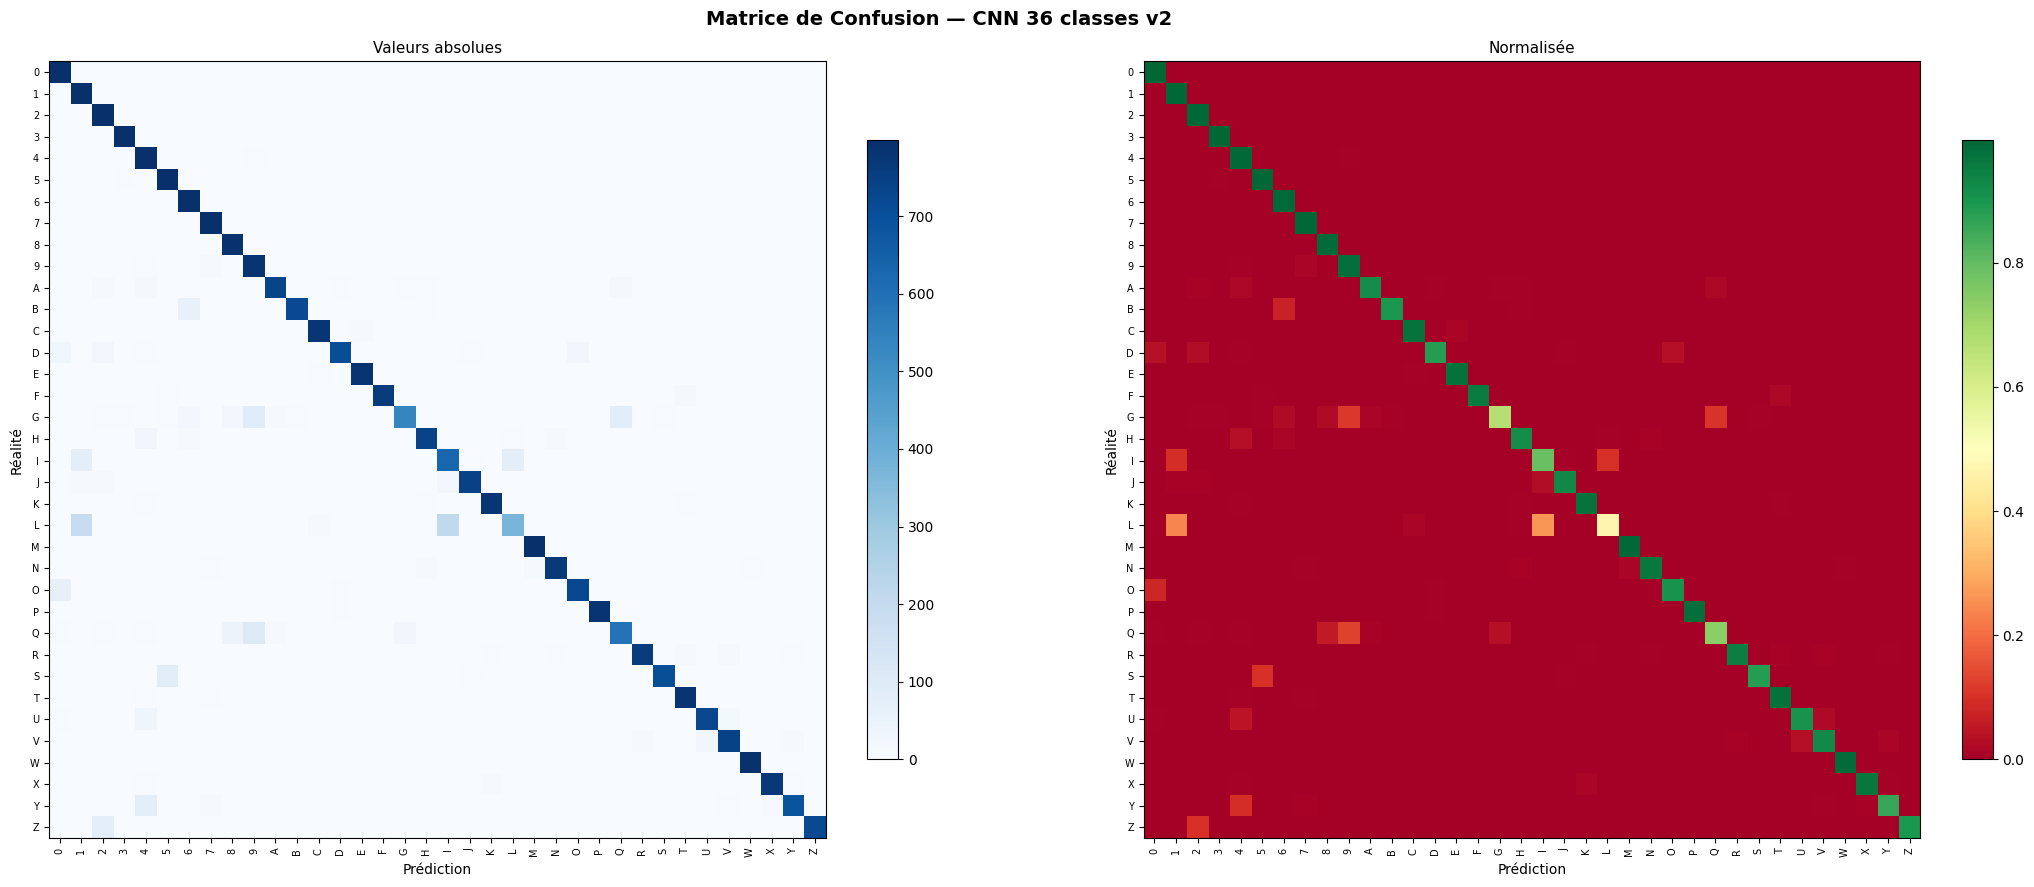

✅ Matrice sauvegardée : matrice_confusion.png


In [ ]:
# ── Matrice de confusion ────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, classes,
                          save_path='matrice_confusion.png'):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle("Matrice de Confusion — CNN 36 classes v2",
                 fontsize=14, fontweight='bold')

    for ax, data, title, cmap, fmt in [
        (axes[0], cm,      'Valeurs absolues', 'Blues',   'd'),
        (axes[1], cm_norm, 'Normalisée',       'RdYlGn', '.2f'),
    ]:
        im = ax.imshow(data, interpolation='nearest', cmap=cmap)
        plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
        ax.set_xticks(range(len(classes)))
        ax.set_yticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=90, fontsize=7)
        ax.set_yticklabels(classes, fontsize=7)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Prédiction')
        ax.set_ylabel('Réalité')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f" Matrice sauvegardée : {save_path}")


plot_confusion_matrix(y_true, y_pred, CLASSES)

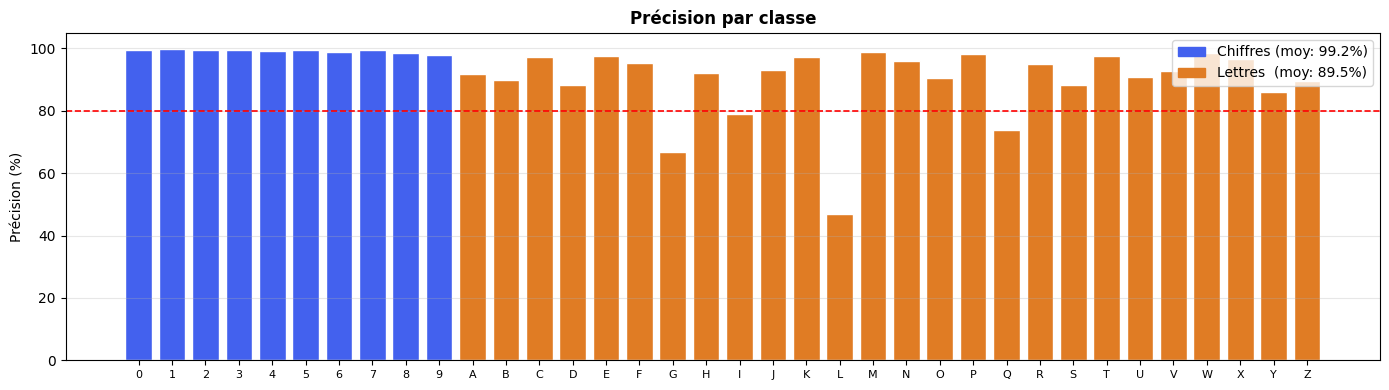

✅ Sauvegardé : precision_par_classe.png
   Précision chiffres (0-9) : 99.22%
   Précision lettres (A-Z)  : 89.50%
   Précision globale        : 92.20%


In [ ]:
# ── Précision par classe ────────────────────────────────────────────────
per_class_acc = confusion_matrix(y_true, y_pred, normalize='true').diagonal()

fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['#4361ee'] * 10 + ['#e07c24'] * 26
ax.bar(range(N_CLASSES), per_class_acc * 100, color=colors, edgecolor='white')
ax.axhline(80, color='red', ls='--', lw=1.2, label='Seuil 80%')
ax.set_xticks(range(N_CLASSES))
ax.set_xticklabels(CLASSES, fontsize=8)
ax.set_ylabel('Précision (%)')
ax.set_ylim(0, 105)
ax.set_title('Précision par classe', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

legend_patches = [
    Patch(color='#4361ee', label=f'Chiffres (moy: {per_class_acc[:10].mean()*100:.1f}%)'),
    Patch(color='#e07c24', label=f'Lettres  (moy: {per_class_acc[10:].mean()*100:.1f}%)'),
]
ax.legend(handles=legend_patches)

plt.tight_layout()
plt.savefig('precision_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Sauvegardé : precision_par_classe.png")
print(f"   Précision chiffres (0-9) : {per_class_acc[:10].mean()*100:.2f}%")
print(f"   Précision lettres (A-Z)  : {per_class_acc[10:].mean()*100:.2f}%")
print(f"   Précision globale        : {per_class_acc.mean()*100:.2f}%")

## 9. Test sur données bruitées

Le projet exige que le réseau reconnaisse des **caractères bruités**. On teste 3 types de bruit.

In [19]:
def add_noise(images, noise_type='gaussian', level=0.2):
    """Ajoute du bruit à un batch d'images numpy (N,28,28,1) ou (28,28,1)."""
    img = images.copy()
    if noise_type == 'gaussian':
        return np.clip(img + np.random.normal(0, level, img.shape), 0, 1)

    elif noise_type == 'salt_pepper':
        n = int(level * 28 * 28)
        if img.ndim == 3:          # image unique
            img = img[np.newaxis]  # → (1,28,28,1)
            single = True
        else:
            single = False
        for i in range(len(img)):
            r = np.random.randint(0, 28, n); c = np.random.randint(0, 28, n)
            img[i, r, c] = 1.0
            r = np.random.randint(0, 28, n); c = np.random.randint(0, 28, n)
            img[i, r, c] = 0.0
        return img[0] if single else img

    elif noise_type == 'speckle':
        return np.clip(img + img * np.random.normal(0, level, img.shape), 0, 1)

    return img


def evaluate_noisy(model, X_test, y_test,
                   noise_types=None, noise_levels=None):
    """Évalue le modèle sur données bruitées. Retourne dict de résultats."""
    if noise_types  is None: noise_types  = ['gaussian', 'salt_pepper', 'speckle']
    if noise_levels is None: noise_levels = [0.10, 0.20, 0.30, 0.40]
    results = {}
    for ntype in noise_types:
        results[ntype] = {}
        for level in noise_levels:
            X_noisy = add_noise(X_test.copy(), ntype, level)
            y_pred_n = np.argmax(model.predict(X_noisy, verbose=0), axis=1)
            acc = np.mean(y_pred_n == y_test)
            results[ntype][level] = acc
            print(f"  {ntype:12s}  σ={level:.2f}  →  {acc*100:.2f}%")
    return results


print(f"Baseline (sans bruit) : {acc_test*100:.2f}%\n")
noise_results = evaluate_noisy(best_model, X_test, y_test)

Baseline (sans bruit) : 92.20%

  gaussian      σ=0.10  →  58.85%
  gaussian      σ=0.20  →  20.58%
  gaussian      σ=0.30  →  6.87%
  gaussian      σ=0.40  →  4.06%
  salt_pepper   σ=0.10  →  5.76%
  salt_pepper   σ=0.20  →  3.97%
  salt_pepper   σ=0.30  →  3.52%
  salt_pepper   σ=0.40  →  3.36%
  speckle       σ=0.10  →  90.24%
  speckle       σ=0.20  →  80.29%
  speckle       σ=0.30  →  66.24%
  speckle       σ=0.40  →  52.52%


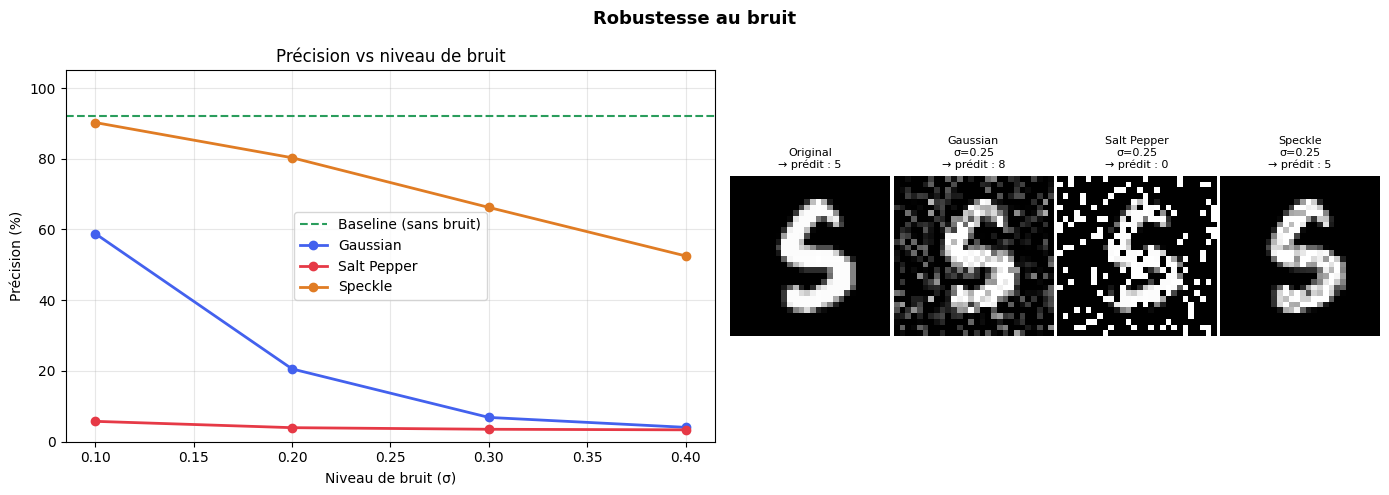

✅ Figure sauvegardée : robustesse_bruit.png


In [ ]:
# ── Visualisation robustesse au bruit ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Robustesse au bruit", fontsize=13, fontweight='bold')

# Courbes précision vs niveau de bruit
ax = axes[0]
colors_noise = {'gaussian': '#4361ee', 'salt_pepper': '#e63946', 'speckle': '#e07c24'}
levels = sorted(list(noise_results['gaussian'].keys()))
ax.axhline(acc_test * 100, color='#2a9d5c', ls='--', lw=1.5,
           label='Baseline (sans bruit)')
for ntype, vals in noise_results.items():
    accs = [vals[l] * 100 for l in levels]
    ax.plot(levels, accs, 'o-', color=colors_noise[ntype],
            lw=2, markersize=6, label=ntype.replace('_', ' ').title())
ax.set_xlabel('Niveau de bruit (σ)')
ax.set_ylabel('Précision (%)')
ax.set_title('Précision vs niveau de bruit')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 105)

# Exemples visuels
ax2 = axes[1]
ax2.axis('off')
sample_idx = np.where(y_test == 5)[0][0]
sample     = X_test[sample_idx]
noise_level_viz = 0.25
noise_types_viz = ['gaussian', 'salt_pepper', 'speckle']

imgs   = [sample] + [add_noise(sample.copy(), nt, noise_level_viz)
                     for nt in noise_types_viz]
titles = ['Original'] + [f'{nt.replace("_"," ").title()}\nσ={noise_level_viz}'
                          for nt in noise_types_viz]


inner = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=axes[1].get_subplotspec())
for i, (img, ttl) in enumerate(zip(imgs, titles)):
    a    = fig.add_subplot(inner[i])
    pred = CLASSES[np.argmax(best_model.predict(
                   img.reshape(1, 28, 28, 1), verbose=0))]
    a.imshow(img[:, :, 0], cmap='gray')
    a.set_title(f'{ttl}\n→ prédit : {pred}', fontsize=8)
    a.axis('off')

plt.tight_layout()
plt.savefig('robustesse_bruit.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée : robustesse_bruit.png")

## 10.  Sauvegarde du modèle

In [ ]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Formats de sauvegarde multiples
best_model.save(f'cnn_36classes_{timestamp}.keras')
best_model.save(f'cnn_36classes_{timestamp}.h5')
best_model.save('model_unified.keras')
best_model.save('model_unified.h5')

print(f" Sauvegardé : cnn_36classes_{timestamp}.keras")
print(f" Sauvegardé : cnn_36classes_{timestamp}.h5")
print(f" Alias génériques : model_unified.keras / model_unified.h5")

# ── Résumé final ─────────────────────────────────────────────────────────
print("\n" + "="*50)
print("RÉSUMÉ FINAL")
print("="*50)
print(f"  Modèle         : CNN 36 classes v2 (0-9 + A-Z)")
print(f"  Dataset        : MNIST + EMNIST (équilibré)")
print(f"  Images train   : {len(X_train):,} ({SAMPLES_TRAIN}/classe)")
print(f"  Images test    : {len(X_test):,}  ({SAMPLES_TEST}/classe)")
print(f"  Test Loss      : {loss_test:.4f}")
print(f"  Test Accuracy  : {acc_test*100:.2f}%")
print(f"  Best val acc   : {max(history.history['val_accuracy'])*100:.2f}%")
print(f"  Époques réelles: {len(history.history['loss'])}/{EPOCHS}")
print("="*50)

## 11.  Fonction de prédiction (pour l'interface graphique)

In [ ]:
def predict_char(model, img_array, top_k=5):
    """
    Prédit le caractère dans une image 28×28.

    Paramètre :
      img_array : numpy array (28,28) ou (28,28,1) ou (1,28,28,1)
                  float32 dans [0,1], fond NOIR, tracé BLANC.

    Retourne :
      dict {
        'char'       : str,            # caractère prédit
        'class_idx'  : int,            # index 0-35
        'confidence' : float,          # probabilité principale
        'top_k'      : list[(char,p)], # top-k prédictions
        'probs'      : np.ndarray(36,) # toutes les probabilités
      }
    """
    arr = img_array.astype('float32')
    if arr.ndim == 2:
        arr = arr.reshape(1, 28, 28, 1)
    elif arr.ndim == 3:
        arr = arr.reshape(1, 28, 28, 1)

    probs      = model.predict(arr, verbose=0)[0]
    best_idx   = int(np.argmax(probs))
    top_k_idxs = np.argsort(probs)[::-1][:top_k]

    return {
        'char'      : CLASSES[best_idx],
        'class_idx' : best_idx,
        'confidence': float(probs[best_idx]),
        'top_k'     : [(CLASSES[i], float(probs[i])) for i in top_k_idxs],
        'probs'     : probs,
    }


# ── Test rapide ──────────────────────────────────────────────────────────
test_samples = [
    (X_test[np.where(y_test == 0)[0][0]],  '0'),
    (X_test[np.where(y_test == 9)[0][0]],  '9'),
    (X_test[np.where(y_test == 10)[0][0]], 'A'),
    (X_test[np.where(y_test == 35)[0][0]], 'Z'),
]

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
fig.suptitle("Test de prédiction rapide", fontsize=11, fontweight='bold')

for ax, (img, true_label) in zip(axes, test_samples):
    result = predict_char(best_model, img)
    color  = '#2a9d5c' if result['char'] == true_label else '#e63946'
    ax.imshow(img[:, :, 0], cmap='gray')
    ax.set_title(
        f"Vrai : {true_label}\n"
        f"Prédit : {result['char']} ({result['confidence']*100:.1f}%)",
        fontsize=9, color=color,
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée : test_predictions.png")

## Récapitulatif des fichiers générés

| Fichier | Contenu |
|---|---|
| `best_model.keras` | ✅ Meilleur modèle (ModelCheckpoint) |
| `model_unified.keras` | Alias du meilleur modèle |
| `model_unified.h5` | Alias (format HDF5, compat max) |
| `cnn_36classes_XXXXXX.keras` | Modèle horodaté |
| `training_log.csv` | Log CSV complet de l'entraînement |
| `distribution_classes.png` | Distribution équilibrée des 36 classes |
| `apercu_donnees.png` | Aperçu des données par classe |
| `augmentation_exemples.png` | Exemples d'augmentation |
| `courbes_apprentissage.png` | Loss & Accuracy (train + val) |
| `matrice_confusion.png` | Matrice de confusion (abs + normalisée) |
| `precision_par_classe.png` | Précision par classe (barplot) |
| `robustesse_bruit.png` | Tests bruit gaussien / sel-poivre / speckle |
| `test_predictions.png` | Exemples de prédictions finales |